# 07 — Arc Analysis

Detect and quantify the rise-and-fall of abstract language across literary history.

Uses two regression approaches:
- **Quadratic**: `score ~ year + year²` — tests for inverted-U, estimates peak year
- **Piecewise linear**: two slopes with optimal breakpoint — measures abstracting/concretizing rates

In [1]:
import sys
sys.path.insert(0, '..')
from abstraction.analysis import *
from abstraction.plotting import plot_arc, plot_arc_by_genre

## Load all scored corpora

Single load used throughout the notebook.

In [2]:
combined = load_all_scored()
print(f'{len(combined)} texts, {combined.year.min():.0f}-{combined.year.max():.0f}, {combined.corpus_name.nunique()} corpora')
combined.genre_harmonized.value_counts()

Loading hathi_englit:  57%|█████▊    | 23/40 [00:28<00:19,  1.12s/it]  

  Skipping hathi: No metadata found at /Users/rj416/lltk_data/corpora/hathi


Loading txtlab: 100%|██████████| 40/40 [00:32<00:00,  1.24it/s]           


1515214 texts, -800-9179, 35 corpora


genre_harmonized
Poetry                 405315
Periodical             396988
Fiction                302659
Primary Document       178364
Spoken                  75204
                        37976
Drama                   28861
Criticism               24994
Academic                24048
Essay/Treatise          11096
Nonfiction              10427
Sermon                   6007
Letters                  5221
Biography                3894
Film                      967
Fictional Dialogue        868
Fictional Narration       868
Legal                     636
Political                 227
Dialogue                  176
Oratory                   173
novel                     106
Miscellany                 41
Other                      37
stories                    14
Juvenilia                  10
theatre                     8
autobio                     7
folktales                   7
poetry_mod                  4
essay                       4
poetry_trad                 3
history                

In [3]:
combined[combined.corpus_name == 'hathi_englit'].head()

,id,Abs-Conc.LSN-Hapt.C16,Abs-Conc.LSN-Hapt.C17,Abs-Conc.LSN-Hapt.C18,Abs-Conc.LSN-Hapt.C19,Abs-Conc.LSN-Hapt.C20,Abs-Conc.LSN-Hapt.median,Abs-Conc.LSN-Hapt.orig,Abs-Conc.LSN-Imag.C16,Abs-Conc.LSN-Imag.C17,...,book-title,collection-id,book-part-id,funding-source,year_orig,id_tedjdh,num_words2,periodical,person,length
1275790,chi/086546157,0.814075,0.893323,0.733068,0.725191,0.543270,0.765025,0.772381,0.957735,0.998507,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1275791,chi/086565931,0.157224,0.071100,0.117464,0.095273,0.035937,0.086207,0.302081,0.246199,0.119772,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1275792,chi/102242609,0.444941,0.314395,0.361344,0.232772,0.078548,0.259530,0.462074,0.473650,0.327205,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1275793,chi/29877569,0.173625,0.029372,0.041380,-0.040868,-0.069068,0.011132,0.527863,0.113818,-0.013006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1275794,coo/31924001671233,1.347607,1.285962,1.264047,1.115241,0.947911,1.148674,1.119799,1.199212,1.134536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Canon Fiction: full arc

In [4]:
# Filter canon fiction from combined
df = combined[combined.corpus_name == 'canon_fiction'].copy()
print(f'{len(df)} texts, {df.year.min()}-{df.year.max()}')
df[['id', 'year', 'major_genre', 'Abs-Conc.Median.median']].head()

1803 texts, -800.0-2019.0


,id,year,major_genre,Abs-Conc.Median.median
49461,Addison.Spectator,1711.0,Other,-0.414567
49462,Ammianus.History,391.0,History,-0.348566
49463,AngloSaxon.Beowulf,1000.0,Epic,0.044100
49464,AngloSaxon.Dream of the Rood,900.0,Verse,-0.042556
49465,Anon.1001Nights.1914,900.0,Novella,-0.013767


In [5]:
# Fit the arc (all years)
result = fit_arc(df)
print(summarize_arc(result))

=== ? (1713 texts, 40 bins, 1600-1990) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractness ~1713, R²=0.850
  Piecewise (break 1760): before abstracting -0.1341/century ***, after concretizing +0.3423/century ***, R²=0.896


In [6]:
# Restrict to 1500+ (avoid ancient outliers pulling the peak)
result_1500 = fit_arc(df, min_year=1500)
print(summarize_arc(result_1500))

=== ? (1731 texts, 42 bins, 1500-1990) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractness ~1696, R²=0.801
  Piecewise (break 1760): before abstracting -0.1253/century ***, after concretizing +0.3371/century ***, R²=0.871


## Across norm columns

Does the arc hold regardless of which norm we use?

In [7]:
score_cols = get_score_columns(df)
rows = []
for col in score_cols:
    r = fit_arc(df[df.year >= 1500], score_col=col)
    r['score_col'] = col
    rows.append(r)

norms_df = pd.DataFrame(rows)
# Show: which norms show the expected arc (β₂ > 0 = concreteness U = abstractness inverted-U)
norms_df['has_arc'] = (norms_df['quad_beta2'] > 0) & (norms_df['quad_beta2_p'] < 0.05)
summary = norms_df[['score_col', 'quad_beta2', 'quad_beta2_p', 'quad_peak_year', 'quad_r2', 'has_arc']]
print(f"Norms showing expected arc: {summary.has_arc.sum()} / {len(summary)}")
summary.sort_values('quad_r2', ascending=False)

Norms showing expected arc: 56 / 56


,score_col,quad_beta2,quad_beta2_p,quad_peak_year,quad_r2,has_arc
6,Abs-Conc.LSN-Hapt.orig,0.000007,3.826461e-11,1715.438460,0.886255,True
4,Abs-Conc.LSN-Hapt.C20,0.000009,5.528288e-10,1705.261913,0.882564,True
39,Abs-Conc.Median.C20,0.000009,1.448019e-09,1706.793492,0.871155,True
46,Abs-Conc.PAV-Conc.C20,0.000009,3.888867e-09,1702.676758,0.869382,True
18,Abs-Conc.MRC-Conc.C20,0.000009,2.283450e-09,1705.674233,0.868919,True
32,Abs-Conc.MT-Conc.C20,0.000009,1.228244e-09,1708.779730,0.868902,True
3,Abs-Conc.LSN-Hapt.C19,0.000009,3.635672e-09,1703.797988,0.867929,True
0,Abs-Conc.LSN-Hapt.C16,0.000009,7.860418e-09,1699.984968,0.867357,True
41,Abs-Conc.Median.orig,0.000007,3.845021e-10,1715.099613,0.867289,True
11,Abs-Conc.LSN-Imag.C20,0.000009,4.708049e-09,1704.013367,0.864912,True


## By genre

Does the arc appear within individual genres?

In [8]:
genre_rows = []
for genre, gdf in df[df.year >= 1600].groupby('major_genre'):
    if len(gdf) < 30:
        continue
    r = fit_arc(gdf, score_col='Abs-Conc.Median.median')
    r['genre'] = genre
    genre_rows.append(r)

genre_df = pd.DataFrame(genre_rows)
genre_df['has_arc'] = (genre_df['quad_beta2'] > 0) & (genre_df['quad_beta2_p'] < 0.05)
for _, row in genre_df.iterrows():
    row_d = row.to_dict()
    row_d['corpus'] = row_d.get('genre', '?')
    print(summarize_arc(row_d))
    print()

=== Novel (695 texts, 27 bins, 1720-1990) ===
  Quadratic: abstractness rises then falls (expected arc) n.s., peak abstractness ~1004, R²=0.902
  Piecewise (break 1820): before concretizing +0.2772/century **, after concretizing +0.3600/century ***, R²=0.903

=== Romance (45 texts, 7 bins, 1630-1710) ===
  Quadratic: insufficient data
  Piecewise: insufficient data



## All scored corpora

Run arc fitting across every corpus in `data/scores/v7/`.

In [9]:
# All corpora, per-corpus arc fitting (reuses combined)
all_results = fit_arc_all_corpora(combined_df=combined, min_year=1600)
all_results['has_arc'] = (all_results['quad_beta2'] > 0) & (all_results['quad_beta2_p'] < 0.05)
all_results[['corpus', 'n_texts', 'year_min', 'year_max', 'quad_peak_year', 'quad_beta2_p', 'quad_r2', 'has_arc', 'pw_break_year', 'pw_slope_before', 'pw_slope_after']].sort_values('quad_r2', ascending=False)

,corpus,n_texts,year_min,year_max,quad_peak_year,quad_beta2_p,quad_r2,has_arc,pw_break_year,pw_slope_before,pw_slope_after
6,chicago,18178,1880.0,2000.0,2002.384199,7.169951e-05,0.984475,False,NaN,NaN,NaN
17,gale_amfic,18175,1780.0,1920.0,2067.822320,1.854287e-01,0.955256,False,NaN,NaN,NaN
23,litlab,5397,1700.0,1990.0,1738.582825,2.730121e-06,0.917212,True,1790.0,-0.001420,0.003597
20,hathi_englit,178176,1700.0,1920.0,1762.333069,2.788073e-07,0.911233,True,1820.0,-0.000166,0.002776
19,hathi_bio,3572,1700.0,1990.0,1739.169212,8.173507e-05,0.871076,True,1810.0,-0.000276,0.002488
10,dialnarr,1736,1820.0,1940.0,1259.783339,8.362834e-01,0.862970,False,NaN,NaN,NaN
5,chadwyck_poetry,271923,1600.0,2000.0,1680.914978,5.718850e-07,0.851881,True,1720.0,-0.001608,0.002507
2,canon_fiction,1713,1600.0,1990.0,1712.735900,3.587488e-09,0.849626,True,1760.0,-0.001341,0.003423
24,long_arc_prestige,3658,1810.0,1940.0,1822.098522,5.435911e-02,0.804187,False,NaN,NaN,NaN
33,tedjdh,3778,1700.0,1890.0,2111.561777,5.312223e-01,0.786007,False,1790.0,0.001605,0.001571


## Cross-corpus arc by genre (with corpus fixed effects)

Pool all scored corpora, harmonize genres, and fit one arc per genre with corpus dummy variables absorbing baseline differences.

In [10]:
genre_results = fit_arc_all_by_genre(combined_df=combined, corpus_fixed_effects=True)
for _, row in genre_results.iterrows():
    print(summarize_arc(row.to_dict()))
    print()

=== Academic (9940 texts, 2 bins, 1 corpora, 1990-2000) ===
  Quadratic: insufficient data
  Piecewise: insufficient data

=== Biography (3890 texts, 60 bins, 4 corpora, 1700-1990) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractness ~1772, R²=0.716
  Piecewise (break 1810): before abstracting -0.0922/century *, after concretizing +0.2585/century ***, R²=0.743

=== Criticism (17527 texts, 41 bins, 1 corpora, 1600-2000) ===
  Quadratic: abstractness rises then falls (expected arc) n.s., peak abstractness ~1594, R²=0.115
  Piecewise (break 1690): before abstracting -0.0682/century n.s., after concretizing +0.0309/century **, R²=0.186

=== Dialogue (145 texts, 16 bins, 1 corpora, 1600-1750) ===
  Quadratic: abstractness rises then falls (expected arc) n.s., peak abstractness ~1679, R²=0.236
  Piecewise: insufficient data

=== Drama (25825 texts, 125 bins, 7 corpora, 1600-2000) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractn

## Corpus-adjusted arc plots

Remove corpus-level baseline differences and plot the shared time trend. Adjusted points are shifted to a common baseline; the black line is the fitted trend (quadratic or piecewise).

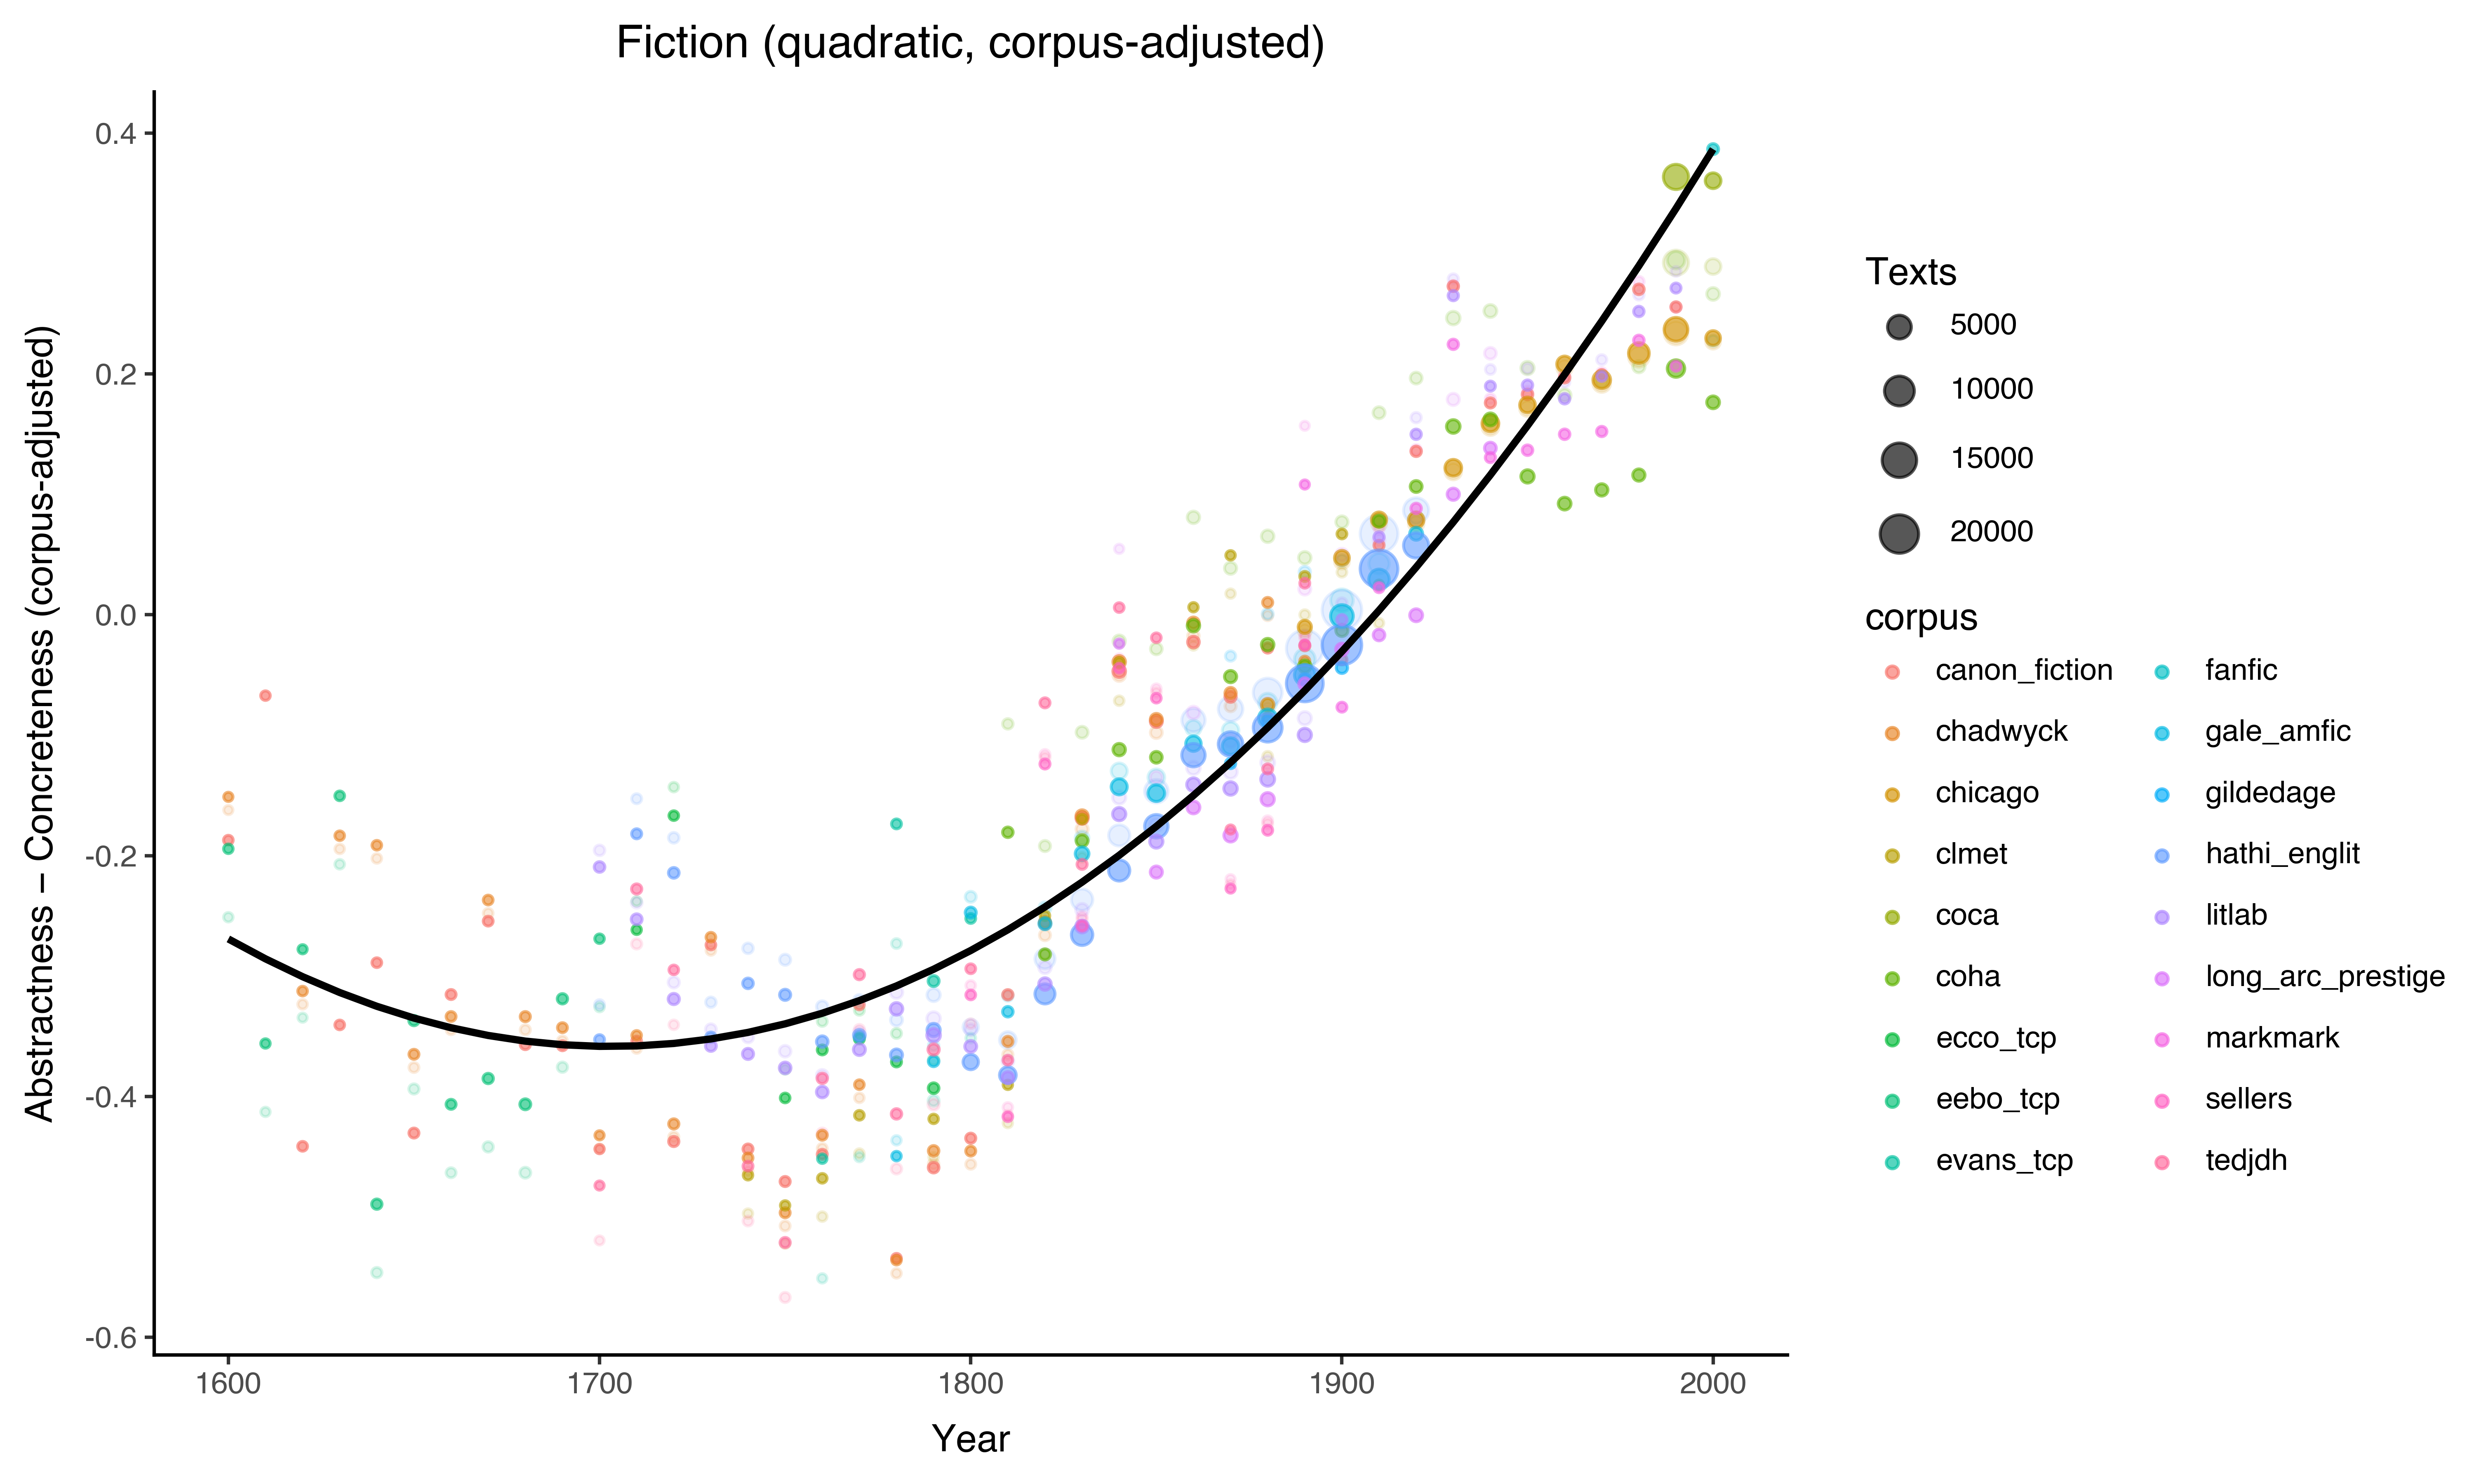

In [11]:
# Single genre: Fiction (quadratic)
fiction = combined[combined.genre_harmonized == 'Fiction']
adj = adjust_scores(fiction, model='quadratic')
plot_arc(adj, title='Fiction (quadratic, corpus-adjusted)')

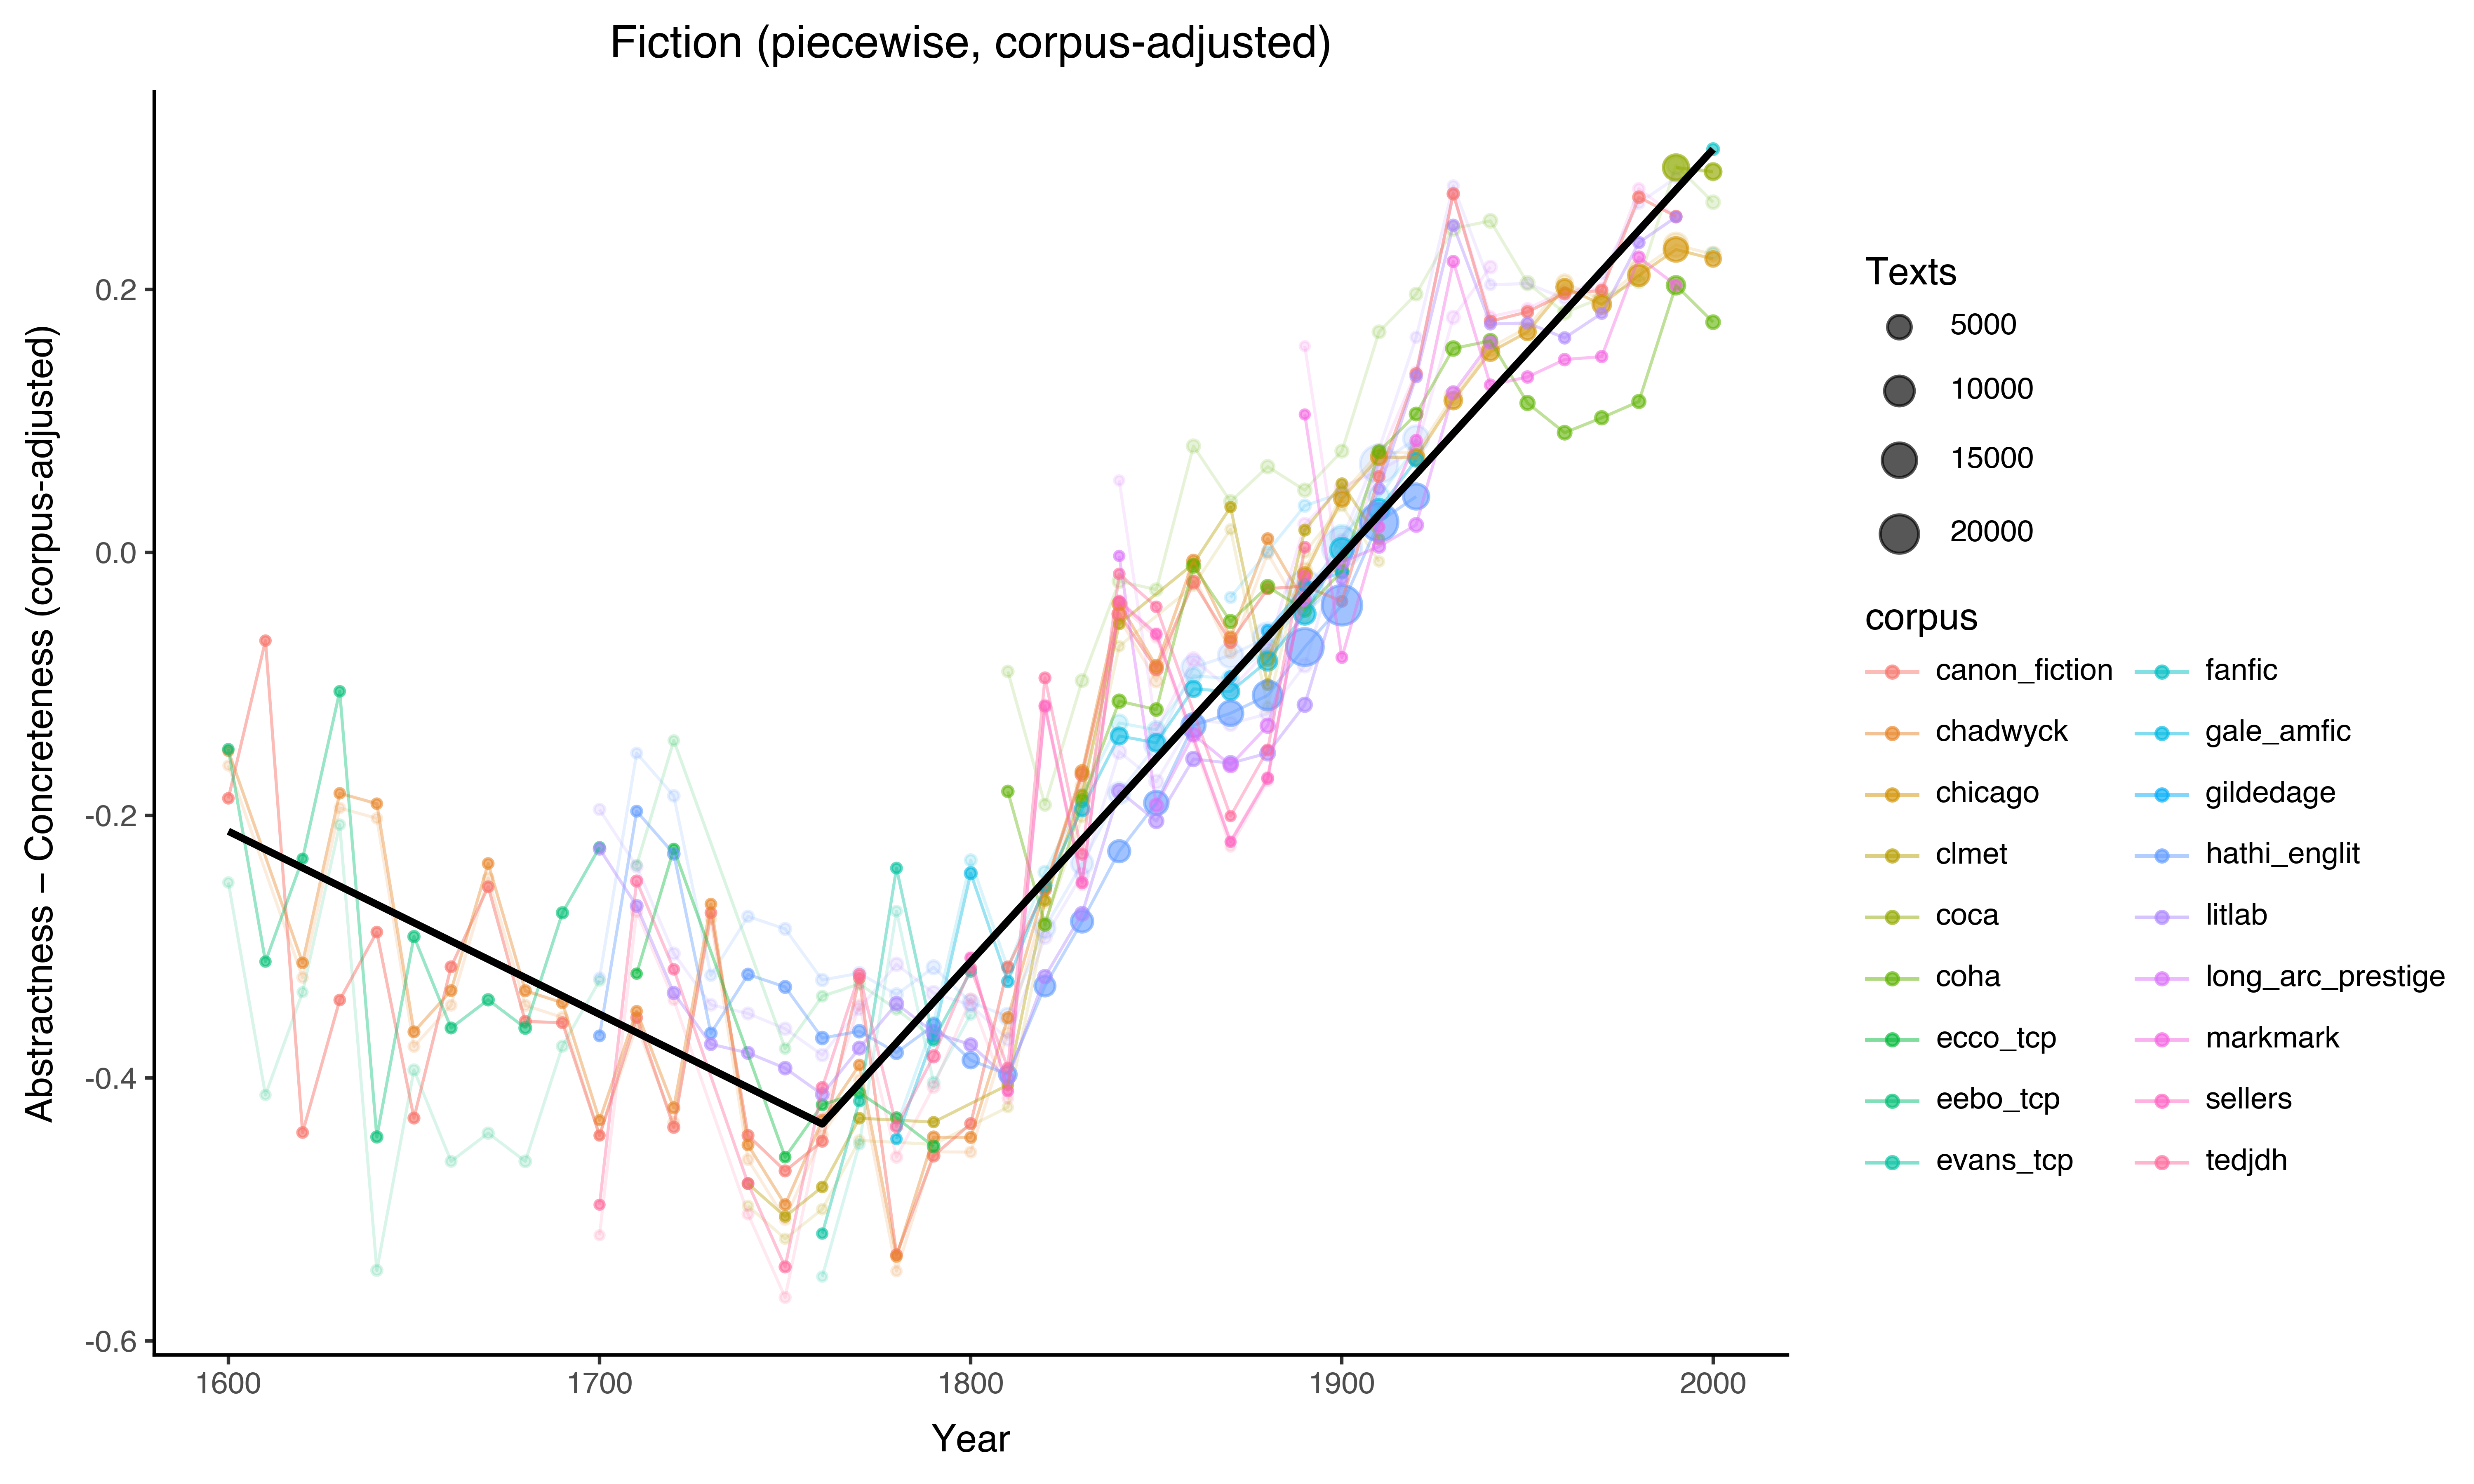

In [17]:
# Single genre: Fiction (piecewise)
adj_pw = adjust_scores(fiction, model='piecewise')
plot_arc(adj_pw, title='Fiction (piecewise, corpus-adjusted)', show_lines=True)

In [13]:
genres = {'Periodical', 'Poetry', 'Fiction', 'Drama'}
combined2 = combined[combined.genre_harmonized.isin(genres)]

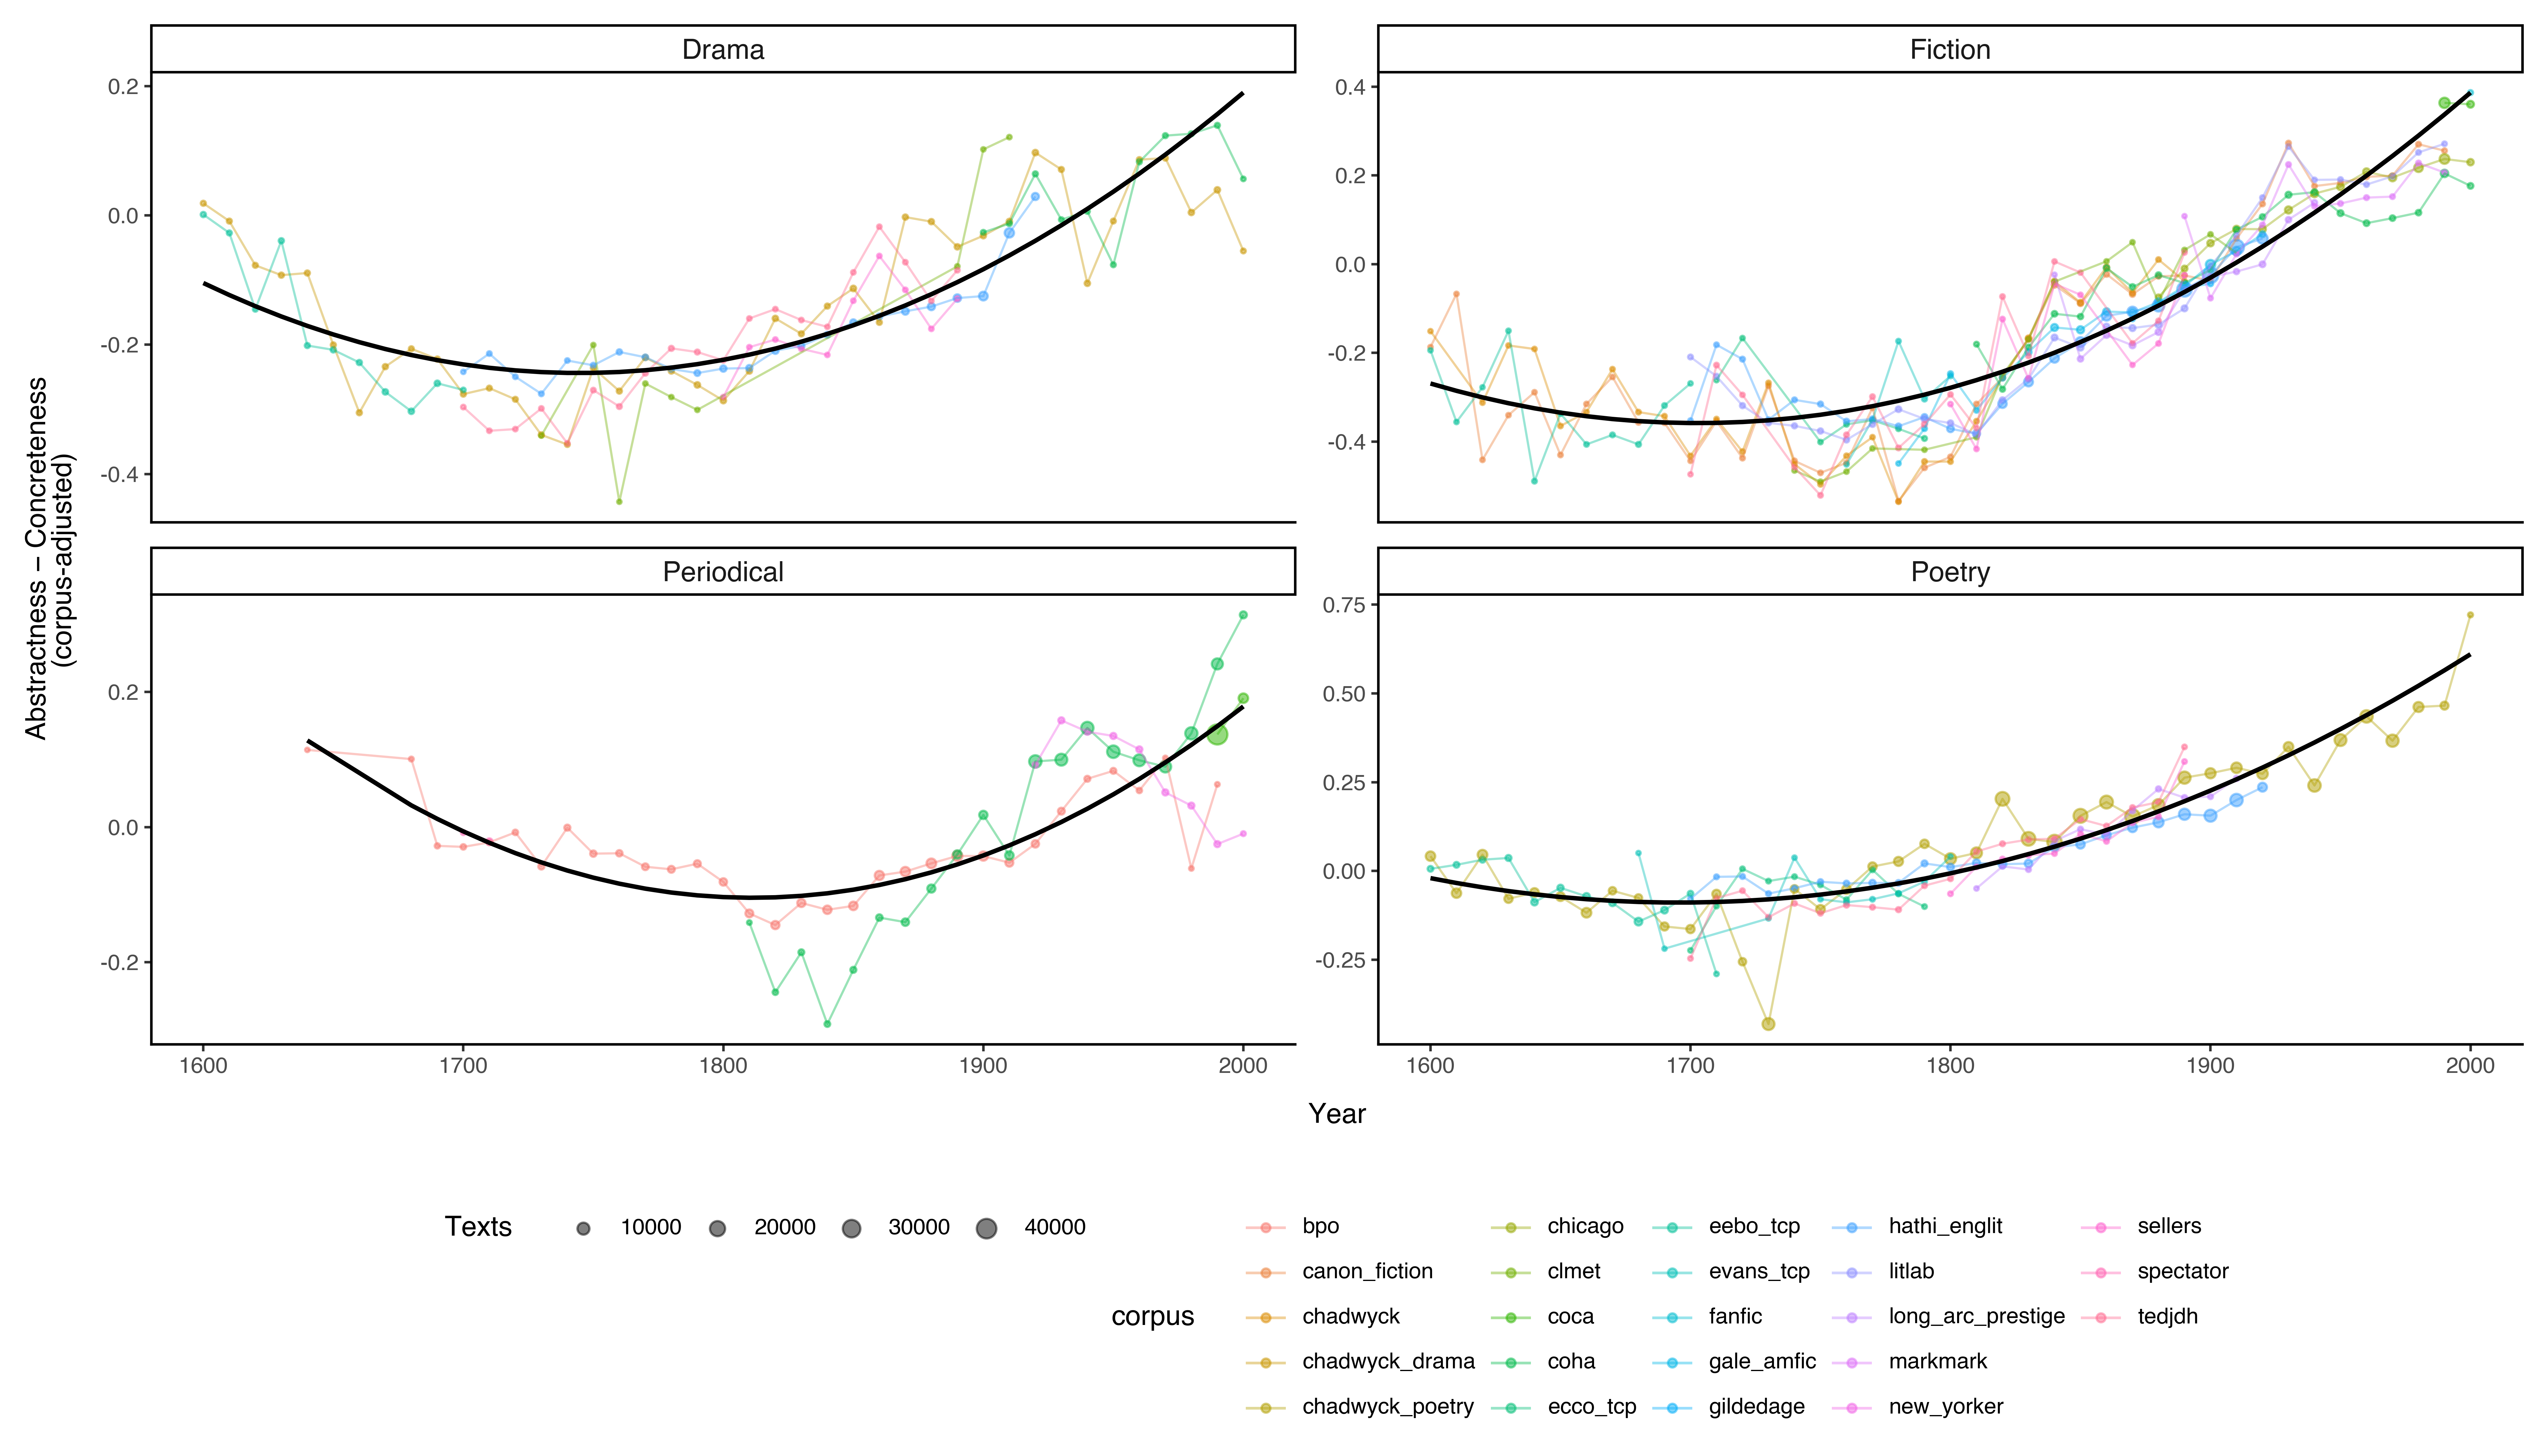

In [16]:
# All genres, faceted (quadratic)
plot_arc_by_genre(combined2, model='quadratic', show_lines=True)

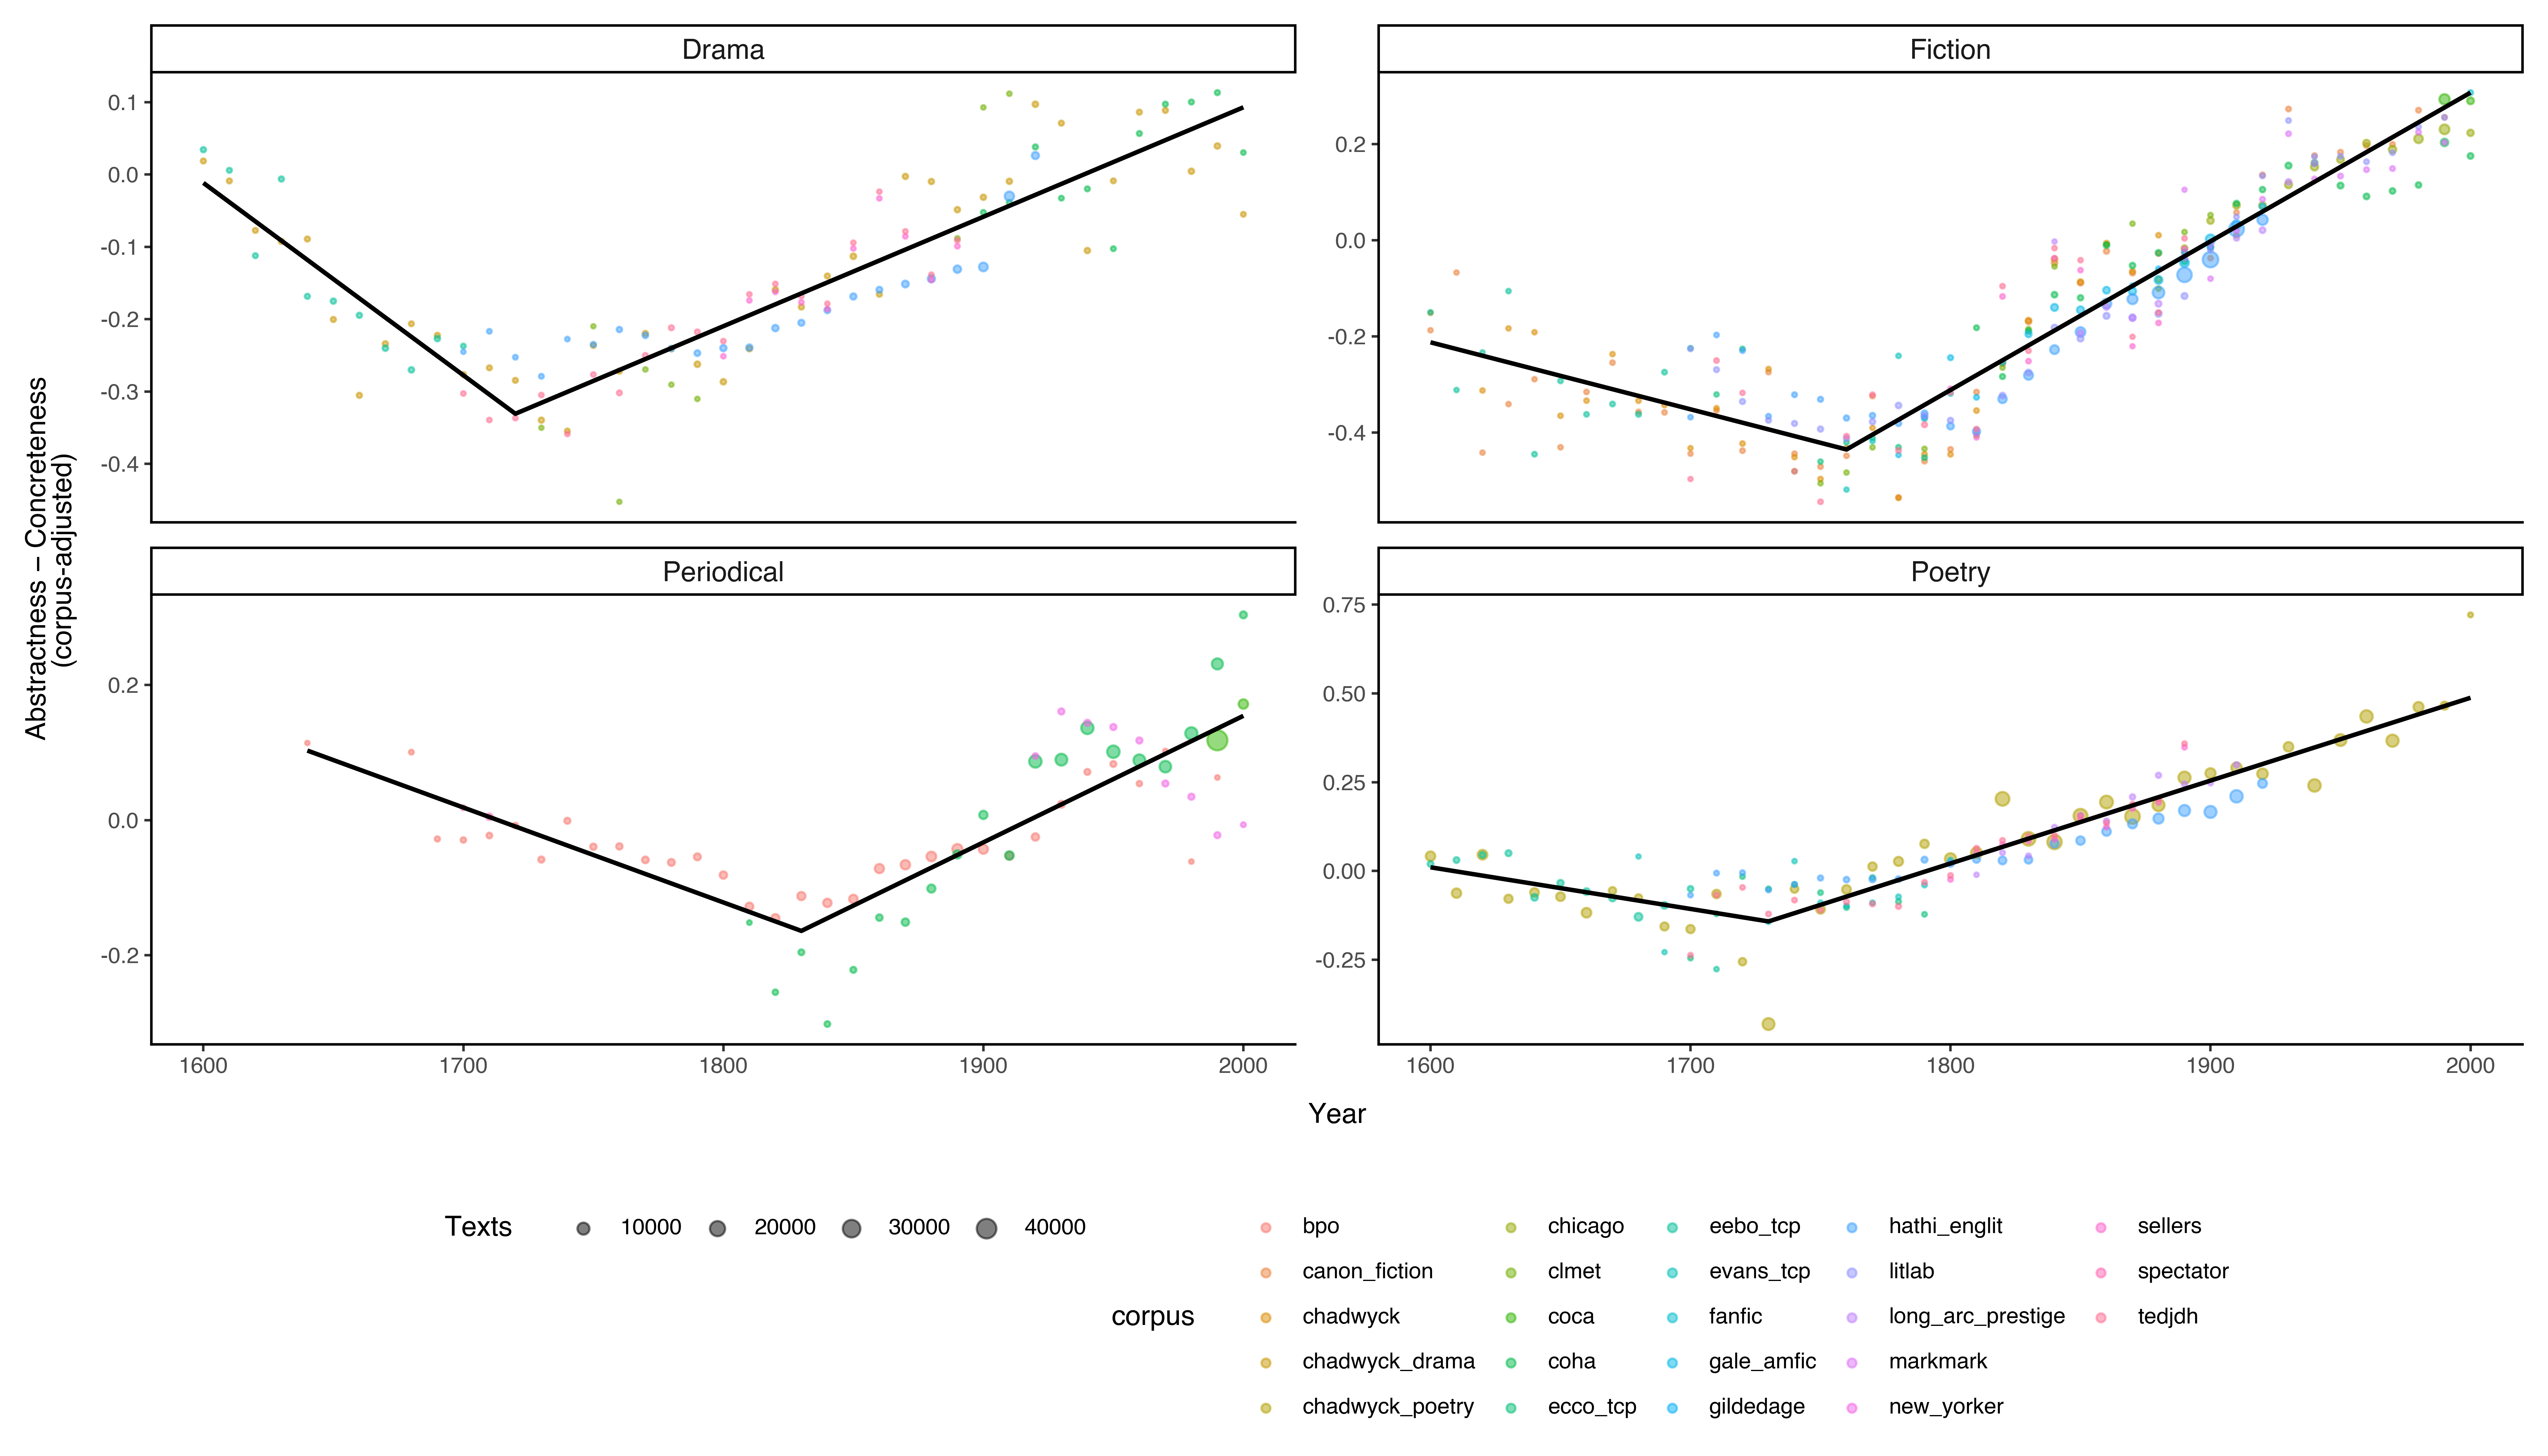

In [15]:
# All genres, faceted (piecewise)
plot_arc_by_genre(combined2, model='piecewise')

In [ ]:
# All genres, combined (no facet) — color by genre, shape by corpus
plot_arc_by_genre(combined2, model='quadratic', show_facet=False, show_lines=True)